# E-Commerce Data RFM 분석을 이용한 고객 세그먼테이션 프로젝트

## 데이터 불러오기

데이터셋 : [UCI Machine Learning Repository](https://archive.ics.uci.edu/)에서 공개한 2010~2011년 이커머스 데이터셋

> SQL 쿼리문으로 RFM 분석이 완료된 `user_data` csv 데이터를 업로드해서 사용

In [1]:
import pandas as pd

user_data = pd.read_csv('user_data.csv')

user_data.head()

,CustomerId,purchase_cnt,item_cnt,recency,user_total,user_average,unique_products,average_interval,total_transactions,cancel_frequency,cancel_rate
0,17850,36,1659,302,5215.8,144.9,24,0.22,321,12,0.04
1,13047,17,1320,46,2945.6,173.3,105,1.51,217,23,0.11
2,12583,18,4928,2,6553.3,364.1,114,1.57,238,3,0.01
3,13748,5,439,95,948.2,189.6,24,10.30,28,0,0.00
4,15100,7,36,330,394.2,56.3,1,5.38,9,3,0.33


## `user_data`를 이용해 클러스터링 적용

- SQL 쿼리문으로 전처리된 데이터를 Python에서 K-Means 클러스터링을 통해 고객 세그먼테이션 및 인사이트와 전략 수립

### 1. 이상 데이터 분석 및 처리

- Z-Score를 사용한 이상치 감지 방법 사용

In [2]:
### 1. 이상 데이터 분석 및 처리
from scipy import stats
import numpy as np 

# Z-score 정의
z_scores = stats.zscore(user_data.iloc[:, 1:], axis = 0)
z_scores = np.abs(z_scores)

print(z_scores)


     purchase_cnt  item_cnt   recency  user_total  user_average  \
0        1.492858  0.103646  1.567891    0.043228      0.405454   
1        0.355374  0.140506  0.413480    0.096560      0.327788   
2        0.415242  0.251795  0.754028    0.125584      0.193996   
3        0.363037  0.236298  0.034233    0.219550      0.283212   
4        0.243302  0.280117  1.784604    0.253663      0.647750   
..            ...       ...       ...         ...           ...   
995      0.243302  0.216726  0.684370    0.216028      0.409009   
996      0.602507  0.273701  1.838782    0.263404      0.156321   
997      0.542640  0.175735  0.732000    0.224636      0.381872   
998      0.482772  0.047867  0.747480    0.146177      1.148960   
999      0.303169  0.188565  0.312863    0.190314      0.153039   

     unique_products  average_interval  total_transactions  cancel_frequency  \
0           0.571802          0.385335            0.325107          0.583077   
1           0.028776          0.276

In [3]:
# 임계값 설정 -> 넘으면 이상치로 간주하는 기준
threshold = 3

# Z-score 기준으로 이상치를 찾아 Outlier 컬럼에 이상치 여부 기입 (0: 정상, 1: 이상치)
user_data['outlier'] = (z_scores > threshold).any(axis=1).astype(int)

user_data.head()

,CustomerId,purchase_cnt,item_cnt,recency,user_total,user_average,unique_products,average_interval,total_transactions,cancel_frequency,cancel_rate,outlier
0,17850,36,1659,302,5215.8,144.9,24,0.22,321,12,0.04,0
1,13047,17,1320,46,2945.6,173.3,105,1.51,217,23,0.11,0
2,12583,18,4928,2,6553.3,364.1,114,1.57,238,3,0.01,0
3,13748,5,439,95,948.2,189.6,24,10.30,28,0,0.00,0
4,15100,7,36,330,394.2,56.3,1,5.38,9,3,0.33,1


/var/folders/92/1z5rtryn4tdg88w4gm0bv9yw0000gn/T/ipykernel_2508/1053709433.py:6: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  outlier_percentage = pd.value_counts(user_data['outlier'], normalize=True) * 100


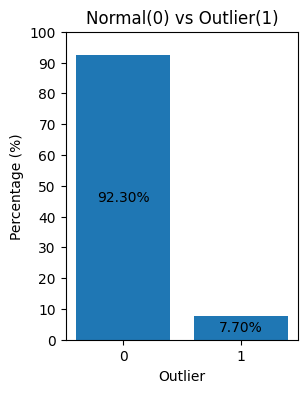

In [4]:
# 시각화에 필요한 라이브러리 불러오기
import matplotlib.pyplot as plt 

# user_data['outlier']을 활용하여 이상치 여부에 따른 확률 계산
# value_counts()는 열의 고윳값의 개수를 반환하지만 normalize=True를 사용하면 열에 있는 값의 개수 비율(상대적 빈도)을 반환
outlier_percentage = pd.value_counts(user_data['outlier'], normalize=True) * 100

plt.figure(figsize=(3, 4))

# outlier_percentage라는 데이터로 bar chart 시각화
# x축 값을 0과 1로 지정
bars = plt.bar(['0', '1'], outlier_percentage)

# 퍼센트(%) 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval/2, f'{yval:.2f}%', fontsize=10, va='center', ha='center')

plt.title('Normal(0) vs Outlier(1)') 
plt.yticks(ticks=np.arange(0, 101, 10)) 
plt.ylabel('Percentage (%)') 
plt.xlabel('Outlier') 
plt.show()

### 시각화 결과

- 약 7.7% 고객이 데이터셋에서 이상치로 식별됨 -> 지워도 크게 문제될 정도는 아닐 수치이므로 제거
- 따라서 'outlier = 0'인 정상 데이터만 유지 ('outlier = 1'인 이상치 값 제거)
- 이상치를 찾는 데 활용된 outlier 컬럼 삭제

In [5]:
# 정상 데이터만 필터링 
user_data = user_data[user_data['outlier'] == 0] 

# outlier 컬럼 삭제 
user_data = user_data.drop(columns=['outlier'])

# DataFrame의 인덱스를 리셋하고, 이전 인덱스를 컬럼으로 추가하지 않음
user_data.reset_index(inplace=True, drop=True)
user_data.head()

,CustomerId,purchase_cnt,item_cnt,recency,user_total,user_average,unique_products,average_interval,total_transactions,cancel_frequency,cancel_rate
0,17850,36,1659,302,5215.8,144.9,24,0.22,321,12,0.04
1,13047,17,1320,46,2945.6,173.3,105,1.51,217,23,0.11
2,12583,18,4928,2,6553.3,364.1,114,1.57,238,3,0.01
3,13748,5,439,95,948.2,189.6,24,10.30,28,0,0.00
4,15291,20,2044,25,4479.7,224.0,62,3.08,114,6,0.05


### 2. 변수 간 상관관계 분석

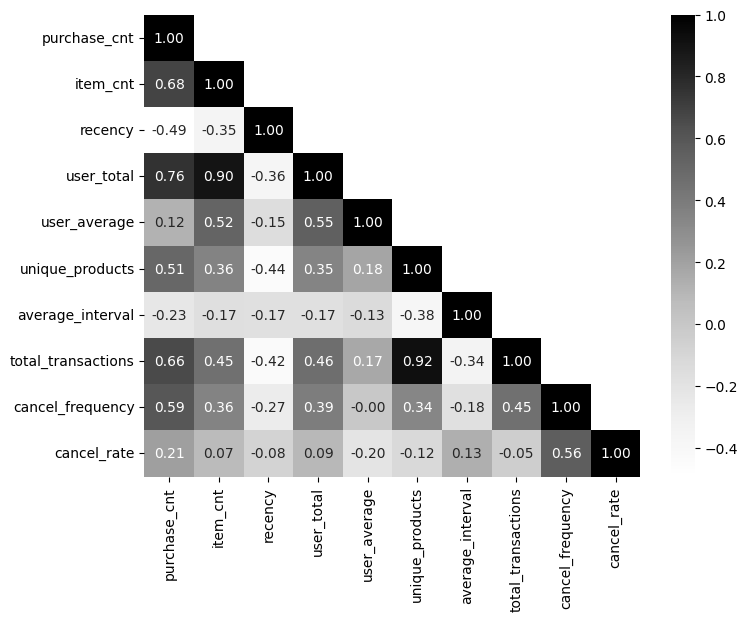

In [7]:
# 시각화 라이브러리 불러오기
import seaborn as sns  

# 'CustomerID' 열을 제외(drop)하고 상관 관계 행렬 계산(corr())
corr = user_data.drop(columns=['CustomerId']).corr()

# 행렬이 대각선을 기준으로 대칭이기 때문에 하단만 표시하기 위한 마스크 생성
mask = np.zeros_like(corr) # np.zeros_like()는 0으로 가득찬 array 생성, 크기는 corr와 동일   
mask[np.triu_indices_from(mask, k=1)] = True # array의 대각선 영역과 그 윗 부분에 True가 들어가도록 설정

# 히트맵 그리기
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, cmap='Greys', annot=True, fmt='.2f')
plt.show()

- `total_transactions`와 `unique_products`가 **0.92** 가장 높은 상관 관계를 갖는다.
- 이외에 `user_total`와 `item_cnt`가 **0.90**으로 역시 높은 상관 관계를 보인다.

### 3. 피처 스케일링
- 범주형 컬럼인 `CustomerId` 컬럼을 제외한 모든 컬럼에 평균이 0, 표준편차가 1이 되도록 `StandardScaler` 적용

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 원본 데이터에 영향을 주지 않기 위해 복사 
data = user_data.copy()

# CustomerID를 제외한 데이터에 스케일링 적용
columns_list = data.iloc[:, 1:].columns # iloc: 데이터 특정 값 추출, columns: 데이터프레임의 열 이름 조회 
data[columns_list] = scaler.fit_transform(data[columns_list])

# 스케일링 된 데이터 출력
data.head()


,CustomerId,purchase_cnt,item_cnt,recency,user_total,user_average,unique_products,average_interval,total_transactions,cancel_frequency,cancel_rate
0,17850,3.012234,0.058204,1.613406,0.666754,-0.644007,-0.793771,-0.667876,1.003021,1.486573,0.448046
1,13047,0.862844,-0.091418,-0.407900,0.076138,-0.488117,0.150682,-0.436681,0.390610,3.335773,2.302515
2,12583,0.975970,1.501025,-0.755312,1.014718,0.559198,0.255621,-0.425928,0.514270,-0.026409,-0.346726
3,13748,-0.494665,-0.480261,-0.021010,-0.443506,-0.398645,-0.793771,1.138670,-0.722328,-0.530737,-0.611650
4,15291,1.202222,0.228130,-0.573711,0.475250,-0.209821,-0.350694,-0.155305,-0.215912,0.477918,0.712970


### 4. 차원축소
- 다중공선성을 제거해 분석 결과의 편향 방지
- 연산속도 향상으로 클러스터링이 잘되게 끔 한다

- 다양한 기법 중 가장 근본적인 주성분분석(PCA) 적용
- PCA는 데이터 내 선형관계를 잘 포착하고, 다중공선성이 있는 데이터셋에 효율적이기 때문이다

In [10]:
from sklearn.decomposition import PCA

# CustomerID를 인덱스로 지정  
data.set_index('CustomerId', inplace=True)

# PCA 적용
pca = PCA().fit(data)

# Explained Variance의 누적합 계산  
explained_variance_ratio = pca.explained_variance_ratio_ # Explained Variance 비율을 계산
cumulative_explained_variance = np.cumsum(explained_variance_ratio) # 각 원소의 누적합을 계산



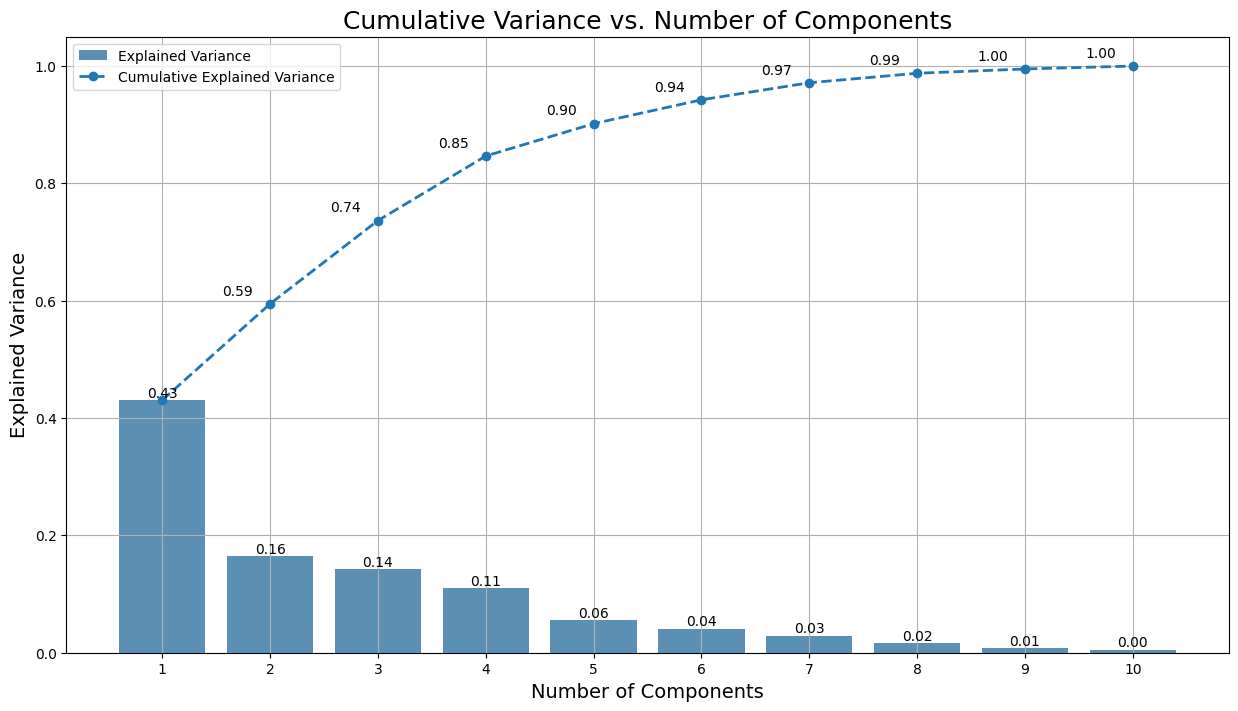

In [11]:
plt.figure(figsize=(15, 8)) 

# 각 성분의 설명된 분포에 대한 막대 그래프
barplot = sns.barplot(x=list(range(1, len(cumulative_explained_variance) + 1)), y=explained_variance_ratio, alpha=0.8)

# 누적 분포에 대한 선 그래프
lineplot, = plt.plot(range(0, len(cumulative_explained_variance)), cumulative_explained_variance, marker='o', linestyle='--', linewidth=2)

# 레이블과 제목 설정
plt.xlabel('Number of Components', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Cumulative Variance vs. Number of Components', fontsize=18)

# 눈금 및 범례 사용자 정의
plt.xticks(range(0, len(cumulative_explained_variance)))
plt.legend(handles=[barplot.patches[0], lineplot],
           labels=['Explained Variance', 'Cumulative Explained Variance'])  

# 두 그래프의 분산 값 표시
x_offset = -0.3
y_offset = 0.01
for i, (ev_ratio, cum_ev_ratio) in enumerate(zip(explained_variance_ratio, cumulative_explained_variance)):
    plt.text(i, ev_ratio, f"{ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)
    if i > 0:
        plt.text(i + x_offset, cum_ev_ratio + y_offset, f"{cum_ev_ratio:.2f}", ha="center", va="bottom", fontsize=10)

plt.grid(axis='both')   
plt.show()

In [12]:
# 6개의 주성분을 유지하는 PCA 선언 
pca = PCA(n_components=6)

# 기존 data를 pca에 fit_transform
data_pca = pca.fit_transform(data)

# 압축된 데이터 셋 생성
data_pca = pd.DataFrame(data_pca, columns=['PC'+str(i+1) for i in range(pca.n_components_)])

# 인덱스로 빼 두었던 CustomerID 다시 추가
data_pca.index = data.index

In [13]:
data_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6
CustomerId,,,,,,
17850,1.684882,1.390061,0.420293,1.953367,-1.765513,0.810777
13047,1.791445,3.340823,0.560456,1.145296,0.999415,-0.314370
12583,2.048993,-0.669680,-0.681403,-0.070373,-0.586152,-0.342068
13748,-1.587093,-0.017237,-0.542572,-0.885136,-0.394382,0.153956
15291,0.907267,1.014741,-0.447068,0.151476,-0.541469,-0.633136


### 5. K-Means 클러스터링

In [14]:
from sklearn.cluster import KMeans
from collections import Counter

# k=3개의 클러스터로 K-Means 클러스터링 적용
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, max_iter=100, random_state=0)
kmeans.fit(data_pca)

# 각 클러스터의 빈도수 구하기
cluster_frequencies = Counter(kmeans.labels_) 

# 빈도수에 기반하여 이전 레이블에서 새 레이블로의 매핑 생성
label_mapping = {label: new_label for new_label, (label, _) in 
                 enumerate(cluster_frequencies.most_common())}

# 매핑을 적용하여 새 레이블 얻기
new_labels = np.array([label_mapping[label] for label in kmeans.labels_])

# 원래 데이터셋에 새 클러스터 레이블 추가
user_data['cluster'] = new_labels

# PCA 버전의 데이터셋에 새 클러스터 레이블 추가
data_pca['cluster'] = new_labels

In [15]:
# K-Means 분류된 결과 보기
user_data.head()

,CustomerId,purchase_cnt,item_cnt,recency,user_total,user_average,unique_products,average_interval,total_transactions,cancel_frequency,cancel_rate,cluster
0,17850,36,1659,302,5215.8,144.9,24,0.22,321,12,0.04,2
1,13047,17,1320,46,2945.6,173.3,105,1.51,217,23,0.11,2
2,12583,18,4928,2,6553.3,364.1,114,1.57,238,3,0.01,2
3,13748,5,439,95,948.2,189.6,24,10.30,28,0,0.00,0
4,15291,20,2044,25,4479.7,224.0,62,3.08,114,6,0.05,0


In [16]:
# 각 군집별로 몇 명의 고객이 있는지 확인
user_data.value_counts('cluster')

cluster
0    568
1    194
2    161
Name: count, dtype: int64

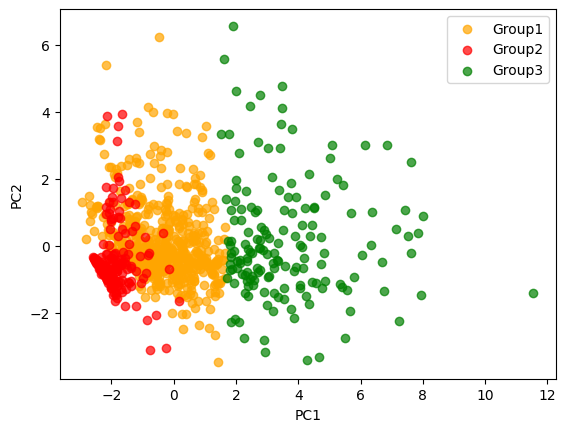

In [17]:
# 각 클러스터 별 데이터 분리 
cluster_0 = data_pca[data_pca['cluster'] == 0]
cluster_1 = data_pca[data_pca['cluster'] == 1]
cluster_2 = data_pca[data_pca['cluster'] == 2]


# 클러스터 별 시각화
plt.scatter(cluster_0['PC1'], cluster_0['PC2'], color = 'orange', alpha = 0.7, label = 'Group1')
plt.scatter(cluster_1['PC1'], cluster_1['PC2'], color = 'red', alpha = 0.7, label = 'Group2')
plt.scatter(cluster_2['PC1'], cluster_2['PC2'], color = 'green', alpha = 0.7, label = 'Group3')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [20]:
!pip3 install plotly==5.18.0

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 15.6 MB 5.4 MB/s eta 0:00:01
  Using cached tenacity-9.1.2-py3-none-any.whl (28 kB)
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [21]:
# 색상 지정 
colors = ['red', 'blue', 'green']

# 각 클러스터별 데이터 분릴
cluster_0 = data_pca[data_pca['cluster'] == 0]
cluster_1 = data_pca[data_pca['cluster'] == 1]
cluster_2 = data_pca[data_pca['cluster'] == 2]

# 3D Scatter Plot 생성
import plotly.graph_objects as go
fig = go.Figure()

# 각 클러스터별 데이터 표기 
fig.add_trace(go.Scatter3d(x=cluster_0['PC1'], y=cluster_0['PC2'], z=cluster_0['PC3'], 
                           mode='markers', marker=dict(color=colors[0], size=5, opacity=0.4), name='Group 1'))
fig.add_trace(go.Scatter3d(x=cluster_1['PC1'], y=cluster_1['PC2'], z=cluster_1['PC3'], 
                           mode='markers', marker=dict(color=colors[1], size=5, opacity=0.4), name='Group 2'))
fig.add_trace(go.Scatter3d(x=cluster_2['PC1'], y=cluster_2['PC2'], z=cluster_2['PC3'], 
                           mode='markers', marker=dict(color=colors[2], size=5, opacity=0.4), name='Group 3'))

# 범례 및 제목 영역 설정
fig.update_layout(
    title=dict(text='3D Visualization of Customer Clusters in PCA Space', x=0.5),
    scene=dict(
        xaxis=dict(backgroundcolor="grey", gridcolor='white', title='PC1'),
        yaxis=dict(backgroundcolor="grey", gridcolor='white', title='PC2'),
        zaxis=dict(backgroundcolor="grey", gridcolor='white', title='PC3'),
    ),
    width=900,
    height=800
)

fig.show()

In [ ]:
# 각 클러스터 별로 어떤 차이가 있는지 추가로 분석 -> 타겟 마케팅 전략 고려
group1 = user_data[user_data['cluster'] == 0]
group2 = user_data[user_data['cluster'] == 1]
group3 = user_data[user_data['cluster'] == 2]

In [23]:
group1.describe()

,CustomerId,purchase_cnt,item_cnt,recency,user_total,user_average,unique_products,average_interval,total_transactions,cancel_frequency,cancel_rate,cluster
count,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.0
mean,15500.609155,7.913732,1073.931338,45.242958,1871.873239,247.693838,80.341549,5.633204,115.809859,1.919014,0.022606,0.0
std,1703.627707,4.919596,878.594441,52.304098,1462.337661,154.513827,54.671050,6.439632,82.027090,3.056861,0.036974,0.0
min,12347.000000,2.000000,-137.000000,0.000000,-108.300000,-27.100000,1.000000,0.650000,2.000000,0.000000,0.000000,0.0
25%,14111.500000,4.000000,412.000000,9.000000,798.200000,150.050000,35.000000,2.037500,49.000000,0.000000,0.000000,0.0
50%,15591.500000,7.000000,869.500000,25.000000,1499.550000,219.050000,72.500000,3.210000,100.000000,1.000000,0.010000,0.0
75%,17027.000000,11.000000,1503.500000,63.000000,2528.025000,305.825000,110.250000,6.552500,161.000000,2.000000,0.030000,0.0
max,18260.000000,39.000000,5195.000000,336.000000,9063.300000,1252.100000,305.000000,39.130000,499.000000,21.000000,0.270000,0.0


In [24]:
group2.describe()

,CustomerId,purchase_cnt,item_cnt,recency,user_total,user_average,unique_products,average_interval,total_transactions,cancel_frequency,cancel_rate,cluster
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.0
mean,15569.912371,2.268041,227.912371,320.592784,432.484021,216.289175,30.427835,1.265052,34.025773,0.463918,0.015000,1.0
std,1712.056258,1.944917,286.595086,62.241250,525.615356,167.758661,27.632628,2.060311,32.417681,1.073099,0.037072,0.0
min,12377.000000,1.000000,-1155.000000,156.000000,-979.000000,-244.800000,1.000000,0.000000,1.000000,0.000000,0.000000,1.0
25%,14164.750000,1.000000,82.250000,281.250000,175.200000,111.925000,10.000000,0.000000,11.000000,0.000000,0.000000,1.0
50%,15727.500000,1.000000,152.500000,357.000000,294.050000,180.550000,22.000000,0.000000,23.000000,0.000000,0.000000,1.0
75%,17028.000000,3.000000,288.750000,366.000000,482.700000,272.875000,42.750000,1.880000,48.500000,0.000000,0.000000,1.0
max,18269.000000,12.000000,2368.000000,373.000000,3969.100000,1141.200000,155.000000,12.310000,199.000000,6.000000,0.220000,1.0


In [25]:
group3.describe()

,CustomerId,purchase_cnt,item_cnt,recency,user_total,user_average,unique_products,average_interval,total_transactions,cancel_frequency,cancel_rate,cluster
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.0
mean,15308.813665,23.080745,4691.490683,13.962733,8084.095652,368.842857,207.763975,1.227267,414.186335,10.770186,0.034534,2.0
std,1776.666261,10.129150,3731.906909,33.204836,6284.464349,241.170814,111.150659,1.124897,224.872609,9.852188,0.038794,0.0
min,12431.000000,5.000000,533.000000,0.000000,1708.100000,91.800000,6.000000,0.220000,26.000000,0.000000,0.000000,2.0
25%,13668.000000,16.000000,2492.000000,2.000000,4212.300000,202.100000,116.000000,0.690000,277.000000,3.000000,0.010000,2.0
50%,15358.000000,21.000000,3773.000000,7.000000,6172.800000,298.800000,211.000000,0.890000,396.000000,8.000000,0.020000,2.0
75%,16873.000000,29.000000,5485.000000,15.000000,9690.200000,461.900000,285.000000,1.280000,510.000000,16.000000,0.050000,2.0
max,18283.000000,58.000000,25643.000000,302.000000,48401.000000,1251.700000,500.000000,9.640000,1272.000000,40.000000,0.230000,2.0
